# 递归 Burg 算法深入研究

## 研究方向

1. **收敛特性**：不同遗忘时间 τ 下反射系数的收敛速度与稳态误差
2. **时变跟踪能力**：合成信号（频率/幅度突变）的跟踪表现
3. **阶数影响**：不同 LPC 阶数 P 的影响
4. **数值稳定性**：长时间运行下的稳定性
5. **与经典自适应算法对比**：递归 Burg vs LMS/RLS
6. **初始化策略**：不同 $A_m(0)$、$B_m(0)$ 初始化方式的影响

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz, lfilter
import os

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False
np.random.seed(42)

# ------------------------------------------------------------
# 复用之前的算法实现
# ------------------------------------------------------------
def block_burg(x, order):
    N = len(x)
    f = x.copy().astype(np.float64)
    b = x.copy().astype(np.float64)
    k = np.zeros(order)
    a = np.array([1.0])
    for m in range(order):
        num = 2.0 * np.sum(f[m+1:] * b[m:N-1])
        den = np.sum(f[m+1:]**2 + b[m:N-1]**2)
        k[m] = -num / den if den > 1e-30 else 0.0
        f_next = f.copy()
        b_next = b.copy()
        f_next[m+1:] = f[m+1:] + k[m] * b[m:N-1]
        b_next[m+1:] = b[m:N-1] + k[m] * f[m+1:]
        f, b = f_next, b_next
        a = np.pad(a, (0, 1), mode='constant')
        for i in range(1, m + 1):
            a[i] += k[m] * a[m - i]
    return a, f.copy(), k

def recursive_burg(x, order, lam=0.995, eps=1e-6):
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    B = np.full(order, eps, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)
    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    a_final = np.ones(order + 1, dtype=dtype)
    for m in range(order):
        k_m = k[m]
        a_prev = a_final.copy()
        a_final[m + 1] = k_m
        for i in range(1, m + 1):
            a_final[i] = a_prev[i] + k_m * a_prev[m - i + 1]
    return a_final, e, k_history

def levinson_from_k(k):
    """从反射系数计算 LPC 系数"""
    P = len(k)
    a = np.ones(P + 1)
    for m in range(P):
        k_m = k[m]
        a_prev = a.copy()
        a[m + 1] = k_m
        for i in range(1, m + 1):
            a[i] = a_prev[i] + k_m * a_prev[m - i + 1]
    return a

---
# 1. 收敛特性

考察不同遗忘时间 τ 对反射系数收敛速度和稳态值的影响。使用 AR(P) 合成信号，其真实反射系数已知，观察递归 Burg 的估计收敛到真值的过程。

In [17]:
# ------------------------------------------------------------
# 1a. 生成 AR(4) 合成信号（已知真实反射系数）
# ------------------------------------------------------------
fs_sim = 48000
N_sim = 8000
t_sim = np.arange(N_sim) / fs_sim

# 真实 AR(4) 系数（对应 4 个共振峰）
true_k = np.array([0.85, -0.65, 0.50, -0.35])
true_a = levinson_from_k(true_k)

# 生成 AR 过程：y[n] = -a1*y[n-1] - a2*y[n-2] - ... + e[n]
wgn = np.random.randn(N_sim + 50) * 0.1
ar_signal = lfilter([1.0], true_a, wgn)[50:]  # 丢弃瞬态

# 预加重
ar_pre = np.append(ar_signal[0], ar_signal[1:] - 0.97 * ar_signal[:-1])

print(f"真实 LPC 系数: {np.array2string(true_a, precision=4)}")
print(f"真实反射系数: {true_k}")

真实 LPC 系数: [ 1.     -0.2025 -0.3258  0.5096 -0.35  ]
真实反射系数: [ 0.85 -0.65  0.5  -0.35]


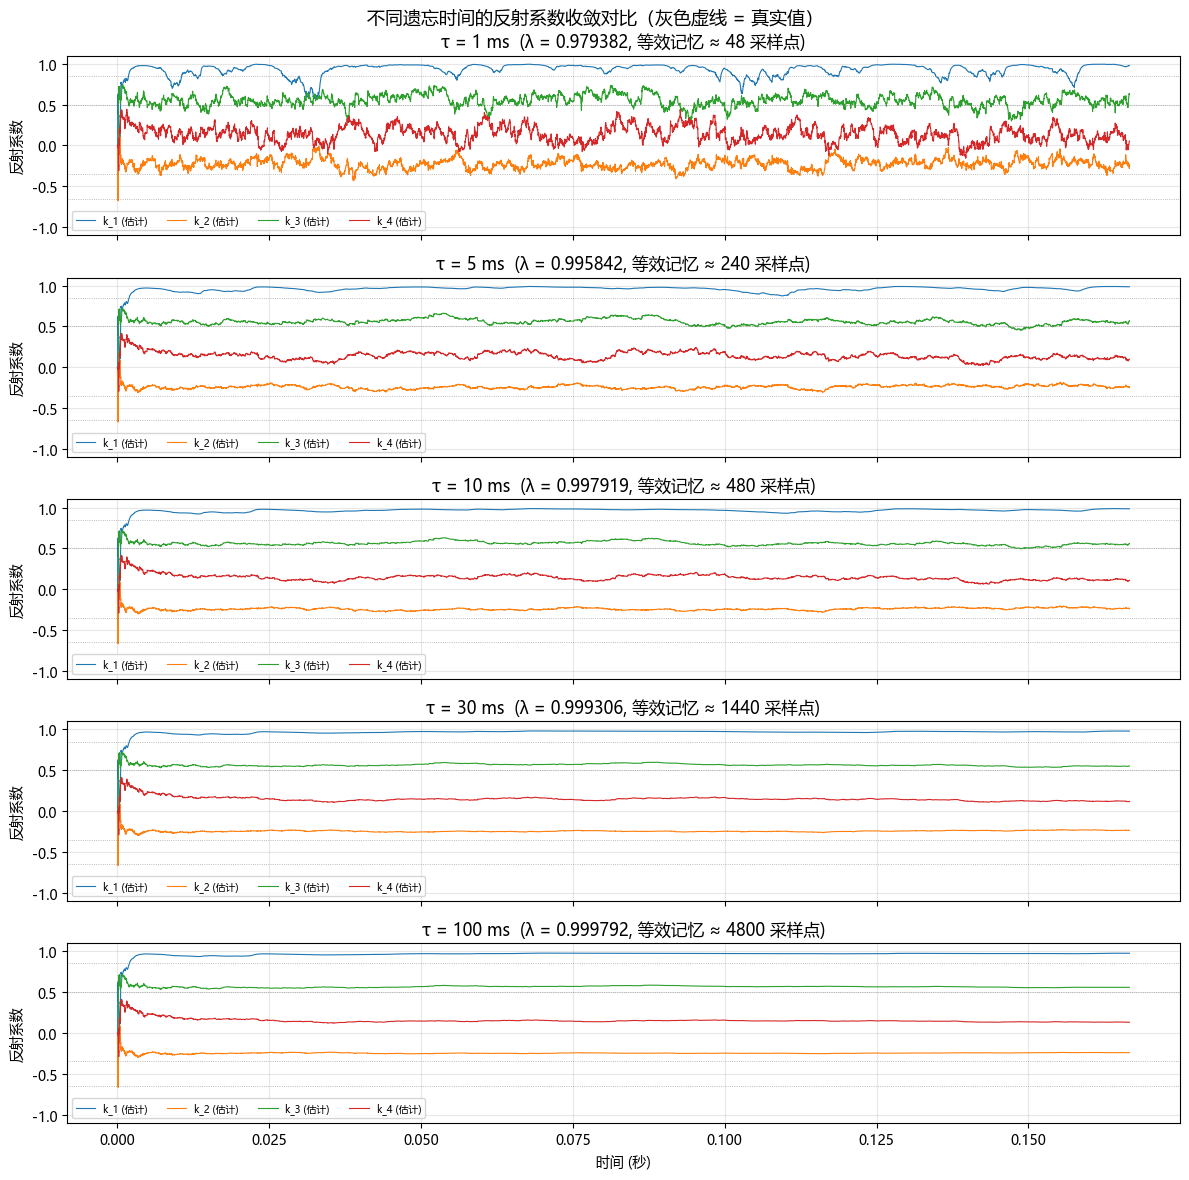

In [18]:
# ------------------------------------------------------------
# 1b. 不同遗忘时间的收敛曲线
# ------------------------------------------------------------
tau_list = [1, 5, 10, 30, 100]  # ms
P = 4

fig, axes = plt.subplots(len(tau_list), 1, figsize=(12, 12), sharex=True)

for i, tau_ms in enumerate(tau_list):
    tau_sec = tau_ms / 1000.0
    lam = np.exp(-1.0 / (tau_sec * fs_sim))
    _, _, k_hist = recursive_burg(ar_pre, P, lam=lam)

    ax = axes[i]
    for m in range(P):
        ax.plot(t_sim, k_hist[:, m], linewidth=0.8, label=f'k_{m+1} (估计)')
    # 真实值水平线
    for m in range(P):
        ax.axhline(y=true_k[m], color='gray', linewidth=0.6, linestyle=':', alpha=0.7)
    ax.set_ylabel('反射系数')
    ax.set_title(f'τ = {tau_ms} ms  (λ = {lam:.6f}, 等效记忆 ≈ {int(1/(1-lam))} 采样点)')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('不同遗忘时间的反射系数收敛对比（灰色虚线 = 真实值）', fontsize=13)
plt.tight_layout()
plt.show()

---
# 2. 时变跟踪能力

合成一个频率/幅度突变的信号，观察递归 Burg 能否快速跟踪 AR 参数的变化，并与分块 Burg 比较。

In [19]:
# ------------------------------------------------------------
# 2a. 合成时变 AR(2) 信号
# ------------------------------------------------------------
N_tv = 12000
switch_point = N_tv // 2

# 两组 AR(2) 系数（前半段/后半段）
true_k1 = np.array([0.80, -0.60])   # 共振峰较宽
true_k2 = np.array([0.92, -0.85])   # 共振峰较窄（更尖）
true_a1 = levinson_from_k(true_k1)
true_a2 = levinson_from_k(true_k2)

wgn = np.random.randn(N_tv + 50) * 0.05
ar1 = lfilter([1.0], true_a1, wgn[:N_tv//2 + 50])[50:]
ar2 = lfilter([1.0], true_a2, wgn[N_tv//2:])[50:]
ar_tv = np.concatenate([ar1, ar2])

t_tv = np.arange(N_tv) / fs_sim
print(f"前半段真实 k: {true_k1}  后半段真实 k: {true_k2}")

前半段真实 k: [ 0.8 -0.6]  后半段真实 k: [ 0.92 -0.85]


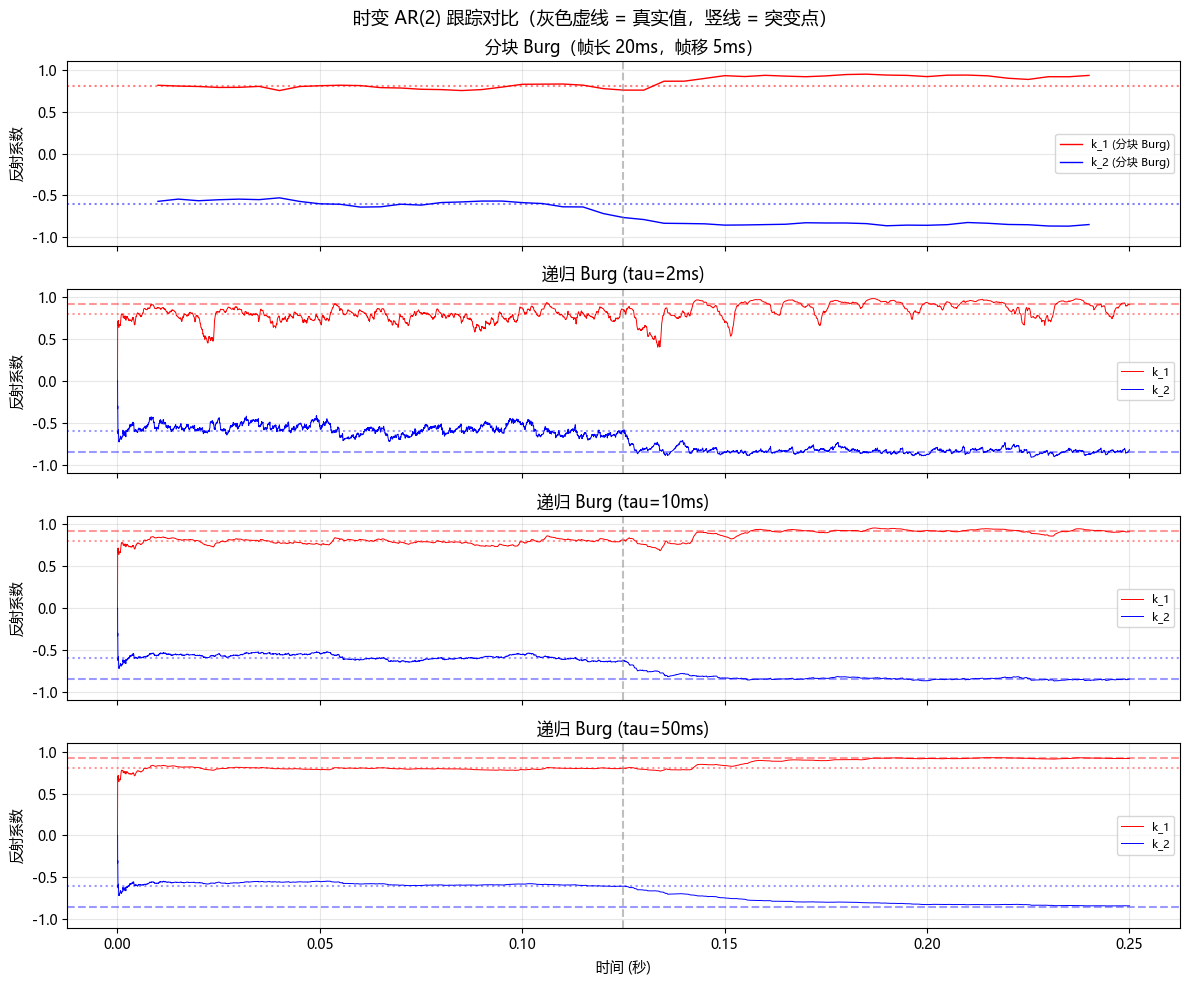

In [25]:
# ------------------------------------------------------------
# 2b. 跟踪对比：递归 Burg (多 tau) vs 分块 Burg
# ------------------------------------------------------------
P_tv = 2
tau_list_tv = [2, 10, 50]  # ms

fig, axes = plt.subplots(len(tau_list_tv) + 1, 1, figsize=(12, 10), sharex=True)

# 分块 Burg（逐帧）
frame_ms = 20
hop_ms = 5
frame_len = int(frame_ms * fs_sim / 1000)
hop_len = int(hop_ms * fs_sim / 1000)
n_frames = 1 + (N_tv - frame_len) // hop_len
k_block_hist = np.zeros((n_frames, P_tv))
for idx in range(n_frames):
    s = idx * hop_len
    a_f, _, k_f = block_burg(ar_tv[s:s+frame_len], P_tv)
    k_block_hist[idx] = k_f
t_block = (np.arange(n_frames) * hop_len + frame_len / 2) / fs_sim

axes[0].plot(t_block, k_block_hist[:, 0], 'r-', linewidth=1.0, label='k_1 (分块 Burg)')
axes[0].plot(t_block, k_block_hist[:, 1], 'b-', linewidth=1.0, label='k_2 (分块 Burg)')
axes[0].axhline(true_k1[0], color='r', ls=':', alpha=0.5)
axes[0].axhline(true_k1[1], color='b', ls=':', alpha=0.5)
axes[0].axvline(switch_point / fs_sim, color='gray', ls='--', alpha=0.5)
axes[0].set_ylabel('反射系数')
axes[0].set_title(f'分块 Burg（帧长 {frame_ms}ms，帧移 {hop_ms}ms）')
axes[0].legend(fontsize=8)
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

for i, tau_ms in enumerate(tau_list_tv):
    lam = np.exp(-1.0 / ((tau_ms / 1000.0) * fs_sim))
    _, _, k_hist_tv = recursive_burg(ar_tv, P_tv, lam=lam)
    ax = axes[i + 1]
    ax.plot(t_tv, k_hist_tv[:, 0], 'r-', linewidth=0.7, label='k_1')
    ax.plot(t_tv, k_hist_tv[:, 1], 'b-', linewidth=0.7, label='k_2')
    ax.axhline(true_k1[0], color='r', ls=':', alpha=0.4)
    ax.axhline(true_k1[1], color='b', ls=':', alpha=0.4)
    ax.axhline(true_k2[0], color='r', ls='--', alpha=0.4)
    ax.axhline(true_k2[1], color='b', ls='--', alpha=0.4)
    ax.axvline(switch_point / fs_sim, color='gray', ls='--', alpha=0.5)
    ax.set_ylabel('反射系数')
    ax.set_title(f'递归 Burg (tau={tau_ms}ms)')
    ax.legend(fontsize=8)
    ax.set_ylim(-1.1, 1.1)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('时变 AR(2) 跟踪对比（灰色虚线 = 真实值，竖线 = 突变点）', fontsize=13)
plt.tight_layout()
plt.show()

---
# 3. 阶数影响

考察不同 LPC 阶数 P 下递归 Burg 的残差能量和频谱包络拟合质量。

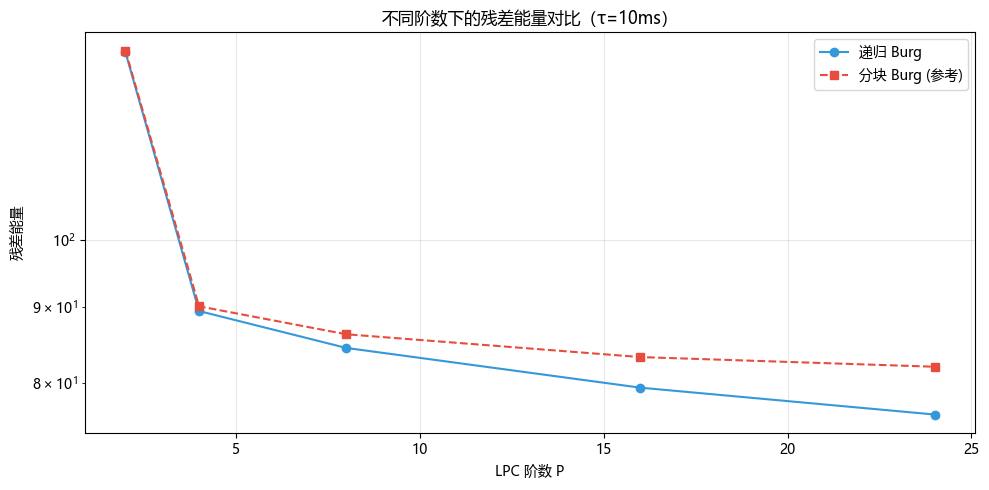

In [21]:
# ------------------------------------------------------------
# 3. 不同阶数下递归 Burg 的残差能量
# ------------------------------------------------------------
order_list = [2, 4, 8, 16, 24]
tau_order = 0.010  # 固定 10ms
lam_order = np.exp(-1.0 / (tau_order * fs_sim))

residual_energy = []
ref_energy = []

for P_o in order_list:
    # 递归
    _, e_rec_o, _ = recursive_burg(ar_pre, P_o, lam=lam_order)
    residual_energy.append(np.sum(e_rec_o**2))
    # 参考：分块 Burg
    a_ref, e_ref, _ = block_burg(ar_pre, P_o)
    ref_energy.append(np.sum(e_ref**2))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(order_list, residual_energy, 'o-', color='#3498db', linewidth=1.5, label='递归 Burg')
ax.semilogy(order_list, ref_energy, 's--', color='#e74c3c', linewidth=1.5, label='分块 Burg (参考)')
ax.set_xlabel('LPC 阶数 P')
ax.set_ylabel('残差能量')
ax.set_title('不同阶数下的残差能量对比（τ=10ms）')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# 4. 数值稳定性

长时间运行下观察反射系数是否越界（|k_m| ≥ 1），以及与分块 Burg 的累积误差对比。使用长段白噪声驱动一个高阶 AR 过程。

全长 100000 采样点，反射系数越界次数: 0


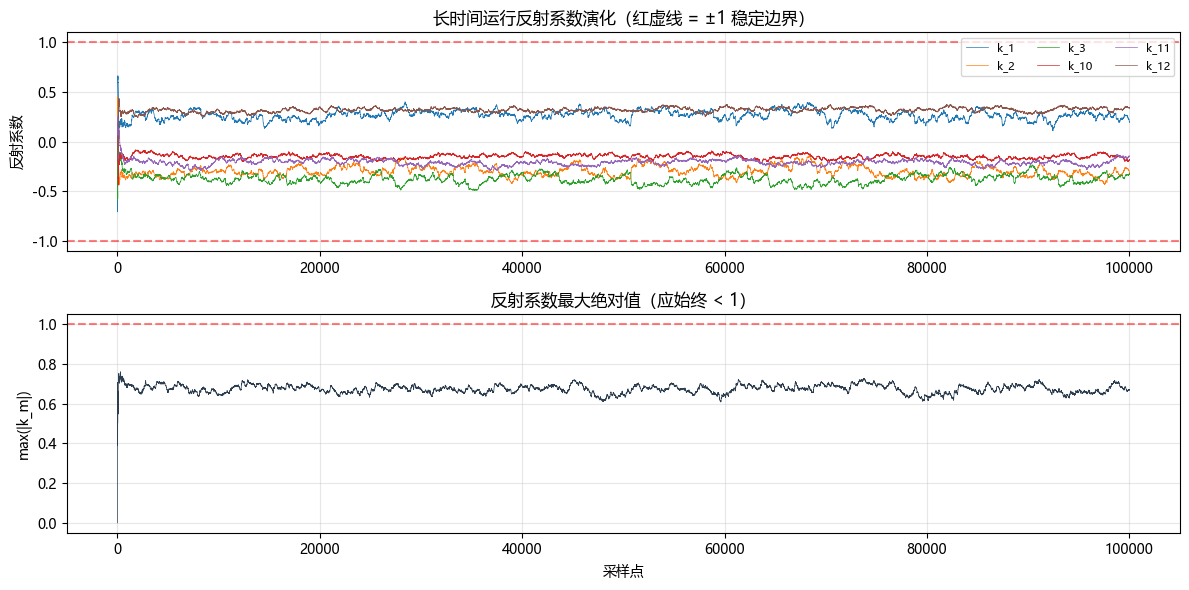

In [22]:
# ------------------------------------------------------------
# 4. 长时间运行数值稳定性
# ------------------------------------------------------------
N_long = 100000
P_long = 12

# 用随机 AR(12) 系数生成信号
np.random.seed(123)
true_k_long = 0.7 * (np.random.rand(P_long) * 2 - 1)  # [-0.7, 0.7]
true_a_long = levinson_from_k(true_k_long)
wgn_long = np.random.randn(N_long + 50) * 0.1
sig_long = lfilter([1.0], true_a_long, wgn_long)[50:]

# 递归 Burg（τ = 20ms）
lam_long = np.exp(-1.0 / (0.020 * fs_sim))
a_long, e_long, k_hist_long = recursive_burg(sig_long, P_long, lam=lam_long)

# 检查反射系数有无越界
k_max_abs = np.max(np.abs(k_hist_long), axis=1)
n_violations = np.sum(k_max_abs >= 1.0)
print(f"全长 {N_long} 采样点，反射系数越界次数: {n_violations}")

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# 子图 1: 反射系数演化（仅显示前几阶和后几阶）
ax1 = axes[0]
for m in [0, 1, 2, P_long-3, P_long-2, P_long-1]:
    ax1.plot(k_hist_long[:, m], linewidth=0.5, label=f'k_{m+1}')
ax1.axhline(1.0, color='red', ls='--', alpha=0.5)
ax1.axhline(-1.0, color='red', ls='--', alpha=0.5)
ax1.set_ylabel('反射系数')
ax1.set_title('长时间运行反射系数演化（红虚线 = ±1 稳定边界）')
ax1.legend(fontsize=8, ncol=3)
ax1.grid(True, alpha=0.3)

# 子图 2: |k_m| 最大值随时间变化
ax2 = axes[1]
ax2.plot(k_max_abs, linewidth=0.5, color='#2c3e50')
ax2.axhline(1.0, color='red', ls='--', alpha=0.5)
ax2.set_xlabel('采样点')
ax2.set_ylabel('max(|k_m|)')
ax2.set_title('反射系数最大绝对值（应始终 < 1）')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 5. 与经典自适应算法对比

递归 Burg vs 标准 RLS 和 LMS 算法的收敛速度与稳态误差对比。用 AR(2) 信号测试。

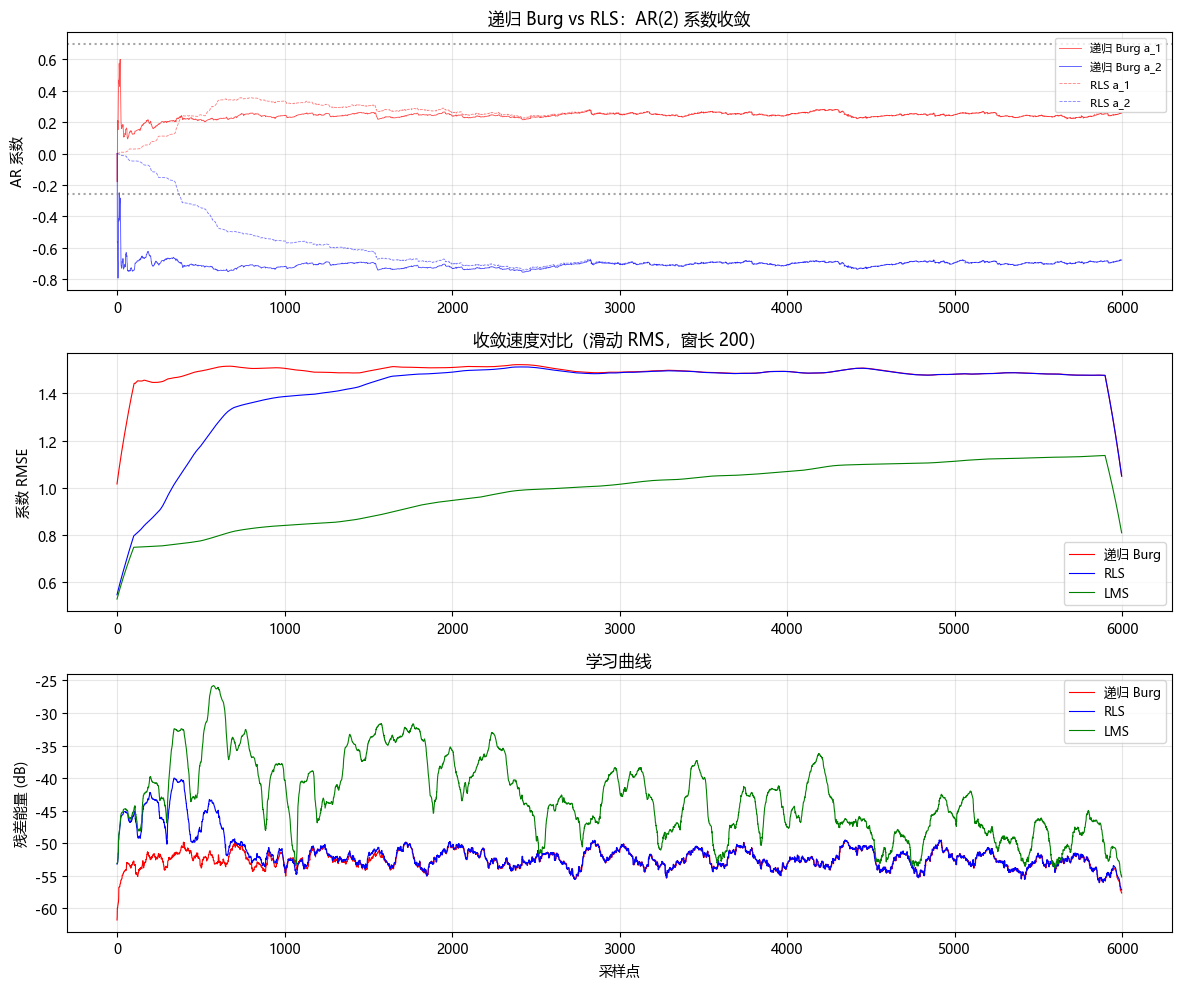

In [23]:
# ------------------------------------------------------------
# 5. 递归 Burg vs RLS vs LMS 收敛对比
# ------------------------------------------------------------
N_compare = 6000
order_cmp = 2
true_k_cmp = np.array([0.85, -0.70])
true_a_cmp = levinson_from_k(true_k_cmp)
wgn_cmp = np.random.randn(N_compare + 50) * 0.05
sig_cmp = lfilter([1.0], true_a_cmp, wgn_cmp)[50:]

def rls_ar(x, order, lam=0.995):
    N = len(x)
    delta = 0.1
    P_mat = delta * np.eye(order)
    w = np.zeros(order)
    e = np.zeros(N)
    w_hist = np.zeros((N, order))
    for n in range(order, N):
        phi = -x[n-order:n][::-1]
        pi_vec = P_mat @ phi
        k_gain = pi_vec / (lam + phi @ pi_vec)
        e[n] = x[n] - w @ phi
        w = w + k_gain * e[n]
        P_mat = (P_mat - np.outer(k_gain, pi_vec)) / lam
        w_hist[n] = w.copy()
    return w_hist[order:], e[order:]

def lms_ar(x, order, mu=0.01):
    N = len(x)
    w = np.zeros(order)
    e = np.zeros(N)
    w_hist = np.zeros((N, order))
    for n in range(order, N):
        phi = -x[n-order:n][::-1]
        e[n] = x[n] - w @ phi
        w = w + mu * e[n] * phi
        w_hist[n] = w.copy()
    return w_hist[order:], e[order:]

lam_cmp = np.exp(-1.0 / (0.010 * fs_sim))
_, e_burg, k_hist_cmp = recursive_burg(sig_cmp, order_cmp, lam=lam_cmp)
a_hist_burg = np.zeros((N_compare, order_cmp + 1))
for n in range(N_compare):
    a_hist_burg[n] = levinson_from_k(k_hist_cmp[n])

w_rls, e_rls = rls_ar(sig_cmp, order_cmp, lam=lam_cmp)
w_lms, e_lms = lms_ar(sig_cmp, order_cmp, mu=0.005)

min_len = min(len(a_hist_burg), len(w_rls), len(w_lms))
a_hist_burg = a_hist_burg[:min_len]
w_rls = w_rls[:min_len]
w_lms = w_lms[:min_len]
e_burg = e_burg[:min_len]
e_rls = e_rls[:min_len]
e_lms = e_lms[:min_len]

def rmse_curve(coef_hist, true_coef, window=200):
    err = coef_hist - true_coef
    sq = np.sum(err**2, axis=1)
    rms = np.sqrt(np.convolve(sq, np.ones(window)/window, mode='same'))
    return rms

rms_burg = rmse_curve(a_hist_burg[:, 1:], -true_a_cmp[1:])
rms_rls = rmse_curve(w_rls, -true_a_cmp[1:])
rms_lms = rmse_curve(w_lms, -true_a_cmp[1:])

fig, axes = plt.subplots(3, 1, figsize=(12, 10))

ax1 = axes[0]
ax1.plot(a_hist_burg[:, 1], 'r-', alpha=0.7, linewidth=0.6, label='递归 Burg a_1')
ax1.plot(a_hist_burg[:, 2], 'b-', alpha=0.7, linewidth=0.6, label='递归 Burg a_2')
ax1.plot(w_rls[:, 0], 'r--', alpha=0.5, linewidth=0.6, label='RLS a_1')
ax1.plot(w_rls[:, 1], 'b--', alpha=0.5, linewidth=0.6, label='RLS a_2')
ax1.axhline(-true_a_cmp[1], color='gray', ls=':', alpha=0.7)
ax1.axhline(-true_a_cmp[2], color='gray', ls=':', alpha=0.7)
ax1.set_ylabel('AR 系数')
ax1.set_title('递归 Burg vs RLS：AR(2) 系数收敛')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(rms_burg, 'r-', linewidth=0.8, label='递归 Burg')
ax2.plot(rms_rls, 'b-', linewidth=0.8, label='RLS')
ax2.plot(rms_lms, 'g-', linewidth=0.8, label='LMS')
ax2.set_ylabel('系数 RMSE')
ax2.set_title('收敛速度对比（滑动 RMS，窗长 200）')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
win_smooth = 100
n_plot = min_len
ax3.plot(20*np.log10(np.convolve(e_burg**2, np.ones(win_smooth)/win_smooth, mode='same')[:n_plot] + 1e-30),
         'r-', linewidth=0.8, label='递归 Burg')
ax3.plot(20*np.log10(np.convolve(e_rls**2, np.ones(win_smooth)/win_smooth, mode='same')[:n_plot] + 1e-30),
         'b-', linewidth=0.8, label='RLS')
ax3.plot(20*np.log10(np.convolve(e_lms**2, np.ones(win_smooth)/win_smooth, mode='same')[:n_plot] + 1e-30),
         'g-', linewidth=0.8, label='LMS')
ax3.set_xlabel('采样点')
ax3.set_ylabel('残差能量 (dB)')
ax3.set_title('学习曲线')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# 6. 初始化策略

考察不同 $A_m(0)$、$B_m(0)$ 初始化方式对收敛速度的影响。
- **策略 A**：$A_m(0) = 0, B_m(0) = \varepsilon$（默认，小常数）
- **策略 B**：$A_m(0) = 0, B_m(0) = \sigma_x^2$（用信号方差初始化）
- **策略 C**：$A_m(0) = 0, B_m(0) = 1.0$（固定较大值）
- **策略 D**：$A_m(0) = 0$，先用前 N_init 样本估算 $B_m(0)$

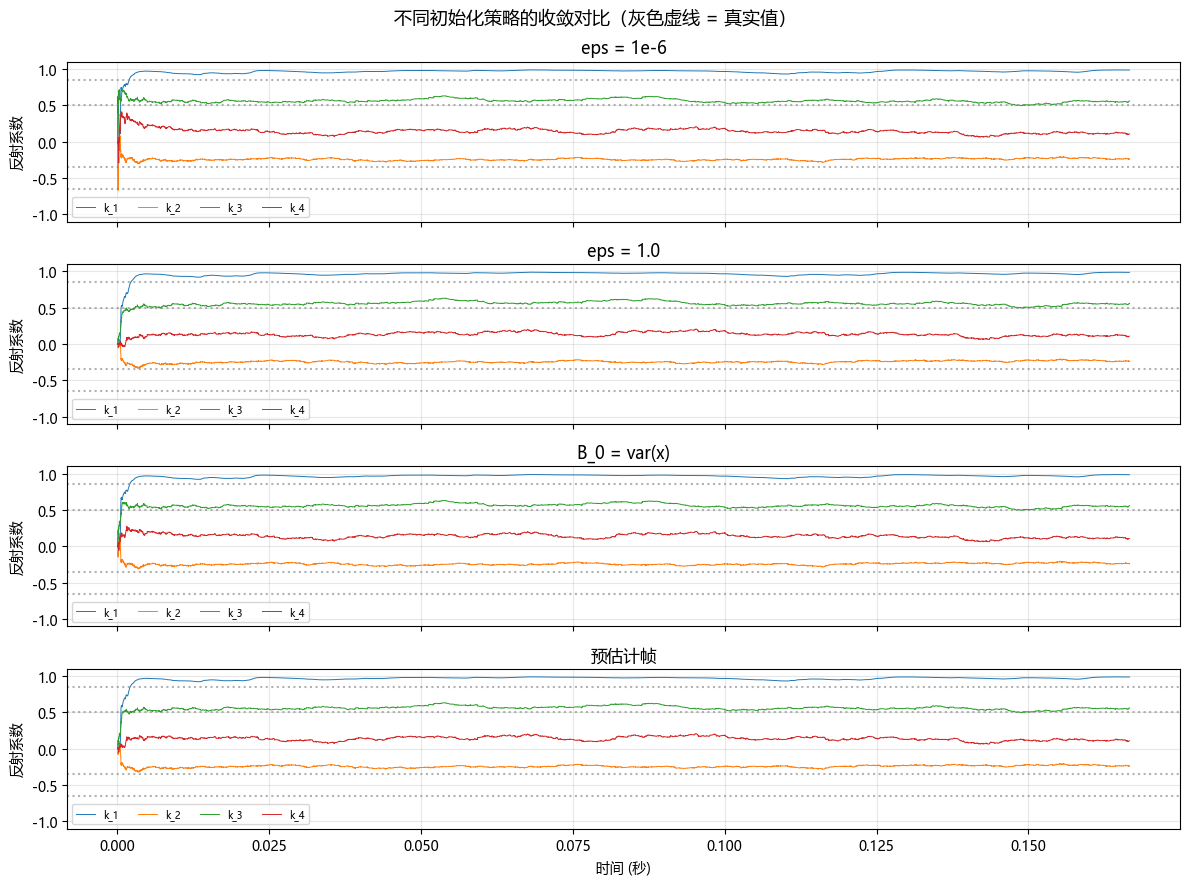

In [24]:
# ------------------------------------------------------------
# 6. 不同初始化策略对比
# ------------------------------------------------------------
def recursive_burg_init(x, order, lam=0.995, init_mode='eps', init_val=1e-6):
    """支持不同初始化策略的递归 Burg"""
    N = len(x)
    dtype = np.float64
    f_curr = np.zeros(order + 1, dtype=dtype)
    b_prev_arr = np.zeros(order + 1, dtype=dtype)
    b_curr = np.zeros(order + 1, dtype=dtype)
    A = np.zeros(order, dtype=dtype)
    k = np.zeros(order, dtype=dtype)
    k_history = np.zeros((N, order), dtype=dtype)
    e = np.zeros(N, dtype=dtype)

    if init_mode == 'eps':
        B = np.full(order, init_val, dtype=dtype)
    elif init_mode == 'var':
        sigma2 = np.var(x[:200]) + 1e-30
        B = np.full(order, sigma2, dtype=dtype)
    elif init_mode == 'one':
        B = np.ones(order, dtype=dtype)
    elif init_mode == 'init_frame':
        init_len = min(256, N // 4)
        _, _, k_init = block_burg(x[:init_len], order)
        sigma2 = np.var(x[:init_len]) + 1e-30
        B = np.full(order, sigma2 / (1 - lam**init_len), dtype=dtype)
    else:
        B = np.full(order, init_val, dtype=dtype)

    for t in range(N):
        f_curr[0] = x[t]
        b_curr[0] = x[t]
        for m in range(order):
            f_m1_t = f_curr[m]
            b_m1_t1 = b_prev_arr[m]
            A[m] = lam * A[m] + f_m1_t * b_m1_t1
            B[m] = lam * B[m] + f_m1_t**2 + b_m1_t1**2
            k[m] = -2.0 * A[m] / B[m] if B[m] > 1e-30 else 0.0
            k[m] = np.clip(k[m], -0.999, 0.999)
            f_curr[m + 1] = f_m1_t + k[m] * b_m1_t1
            b_curr[m + 1] = b_m1_t1 + k[m] * f_m1_t
        k_history[t] = k.copy()
        e[t] = f_curr[order]
        b_prev_arr[:order] = b_curr[:order]
    return k_history, e

P_init = 4
lam_init = np.exp(-1.0 / (0.010 * fs_sim))
init_strategies = {
    'eps = 1e-6': ('eps', 1e-6),
    'eps = 1.0': ('one', 1.0),
    'B_0 = var(x)': ('var', 0),
    '预估计帧': ('init_frame', 0),
}

fig, axes = plt.subplots(len(init_strategies), 1, figsize=(12, 9), sharex=True)

for i, (name, (mode, val)) in enumerate(init_strategies.items()):
    k_hist_i, _ = recursive_burg_init(ar_pre, P_init, lam=lam_init, init_mode=mode, init_val=val)
    ax = axes[i]
    for m in range(P_init):
        ax.plot(t_sim, k_hist_i[:, m], linewidth=0.7, label=f'k_{m+1}')
    for m in range(P_init):
        ax.axhline(y=true_k[m], color='gray', ls=':', alpha=0.6)
    ax.set_ylabel('反射系数')
    ax.set_title(f'{name}')
    ax.set_ylim(-1.1, 1.1)
    ax.legend(fontsize=7, ncol=4)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('时间 (秒)')
plt.suptitle('不同初始化策略的收敛对比（灰色虚线 = 真实值）', fontsize=13)
plt.tight_layout()
plt.show()